In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns

In [4]:
def plot_box_with_points(
    metrics,
    names,
    x_values,
    *,
    x_label="X",
    y_label="Value",
    title=None,
    log_scale_x=False,
    log_scale_y=False,
    palette="Set2", #"Set2", "deep", "tab10"
    save_path=None,
    figsize=(7, 4),
):
    """
    Draw side-by-side boxplots (with seed-level points) for one or multiple metrics
    measured over discrete x-values (e.g., checkpoints, batch sizes, penalty values).

    Args:
        metrics: list of 2D numpy arrays, each shape = (num_x, num_seeds)
        names: list of metric names (same length as metrics)
        x_values: list or array of x-axis values (length = num_x)
        x_label: label for the x-axis
        y_label: label for the y-axis
        title: optional string for figure title
        log_scale_x: bool, whether to use log scale on x-axis
        log_scale_y: bool, whether to use log scale on y-axis
        palette: seaborn color palette name or list of colors
        save_path: optional path (folder or full file) to save the figure
        figsize: tuple, size of the figure
    """
    sns.set_theme(style="whitegrid", font_scale=1.0)
    colors = sns.color_palette(palette, n_colors=len(metrics))

    # --- Convert all metrics into one long-form DataFrame ---
    data = []
    for metric, name in zip(metrics, names):
        for xi, x_val in enumerate(x_values):
            for val in np.ravel(metric[xi]):
                data.append((x_val, name, val))
    df = pd.DataFrame(data, columns=["X", "Metric", "Value"])

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df, x="X", y="Value", hue="Metric",
        palette=colors, width=0.6, ax=ax
    )

    # Overlay seed-level points in matching colors
    sns.stripplot(
        data=df, x="X", y="Value", hue="Metric",
        dodge=True, palette=colors, size=4, jitter=0.15,
        edgecolor="auto", linewidth=0.3, ax=ax, legend=False
    )

    # --- Style ---
    if log_scale_x:
        ax.set_xscale("log")
    if log_scale_y:
        ax.set_yscale("log")

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if title:
        ax.set_title(title, weight="bold")

    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="best")
    plt.tight_layout()

    # --- Save (optional) ---
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        if os.path.isdir(save_path):
            fname = (title or "plot").lower().replace(" ", "_") + ".png"
            save_file = os.path.join(save_path, fname)
        else:
            save_file = save_path
        plt.savefig(save_file, dpi=300, bbox_inches="tight")

    plt.show()


In [5]:
# LOOKING FOR FOLDERS

# filter all folder name in rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000" that contain "finetune_20251030-232939_model_20"

rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"
dir_path_seeds = []
for folder_name in os.listdir(rel_path):
    if "finetune_20251030-233223_model_200" in folder_name:
        dir_path_seeds.append(os.path.join(folder_name))

# print line by line dir_path_seeds
for path in dir_path_seeds:
    print(f"\"{path}\",")

"20251031-003411_MLP_FSNet_seed0_dropout0.1_finetune_20251030-233223_model_200",
"20251031-031359_MLP_FSNet_seed1_dropout0.1_finetune_20251030-233223_model_200",
"20251031-033136_MLP_FSNet_seed2_dropout0.1_finetune_20251030-233223_model_200",
"20251031-034722_MLP_FSNet_seed3_dropout0.1_finetune_20251030-233223_model_200",


In [6]:
# Getting results
rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"

# Suboptimality 0.5 at different checkpoints
# dir_path_seeds = np.array([
#     [
#         "20251031-203828_MLP_FSNet_seed0_dropout0.1",
#         "20251031-205035_MLP_FSNet_seed1_dropout0.1",
#         "20251031-210247_MLP_FSNet_seed2_dropout0.1",
#         "20251031-211532_MLP_FSNet_seed3_dropout0.1"
#     ],
#     [
#         "20251030-234745_MLP_FSNet_seed0_dropout0.1_finetune_20251030-233223_model_20",
#         "20251031-005527_MLP_FSNet_seed1_dropout0.1_finetune_20251030-233223_model_20",
#         "20251031-011053_MLP_FSNet_seed2_dropout0.1_finetune_20251030-233223_model_20",
#         "20251031-012437_MLP_FSNet_seed3_dropout0.1_finetune_20251030-233223_model_20",
#     ],
#     [
#         "20251031-000347_MLP_FSNet_seed0_dropout0.1_finetune_20251030-233223_model_60",
#         "20251031-014015_MLP_FSNet_seed1_dropout0.1_finetune_20251030-233223_model_60",
#         "20251031-015555_MLP_FSNet_seed2_dropout0.1_finetune_20251030-233223_model_60",
#         "20251031-021142_MLP_FSNet_seed3_dropout0.1_finetune_20251030-233223_model_60",
#     ],
#     [
#         "20251031-001737_MLP_FSNet_seed0_dropout0.1_finetune_20251030-233223_model_100",
#         "20251031-022558_MLP_FSNet_seed1_dropout0.1_finetune_20251030-233223_model_100",
#         "20251031-024211_MLP_FSNet_seed2_dropout0.1_finetune_20251030-233223_model_100",
#         "20251031-025820_MLP_FSNet_seed3_dropout0.1_finetune_20251030-233223_model_100",
#     ],
#     [
#         "20251031-003411_MLP_FSNet_seed0_dropout0.1_finetune_20251030-233223_model_200",
#         "20251031-031359_MLP_FSNet_seed1_dropout0.1_finetune_20251030-233223_model_200",
#         "20251031-033136_MLP_FSNet_seed2_dropout0.1_finetune_20251030-233223_model_200",
#         "20251031-034722_MLP_FSNet_seed3_dropout0.1_finetune_20251030-233223_model_200",
#     ]
# ]) # matrix of shape (num_ckpt, num_seeds)

# Suboptimality 0.0 at different checkpoints
dir_path_seeds = np.array([
    [
        "20251031-203828_MLP_FSNet_seed0_dropout0.1",
        "20251031-205035_MLP_FSNet_seed1_dropout0.1",
        "20251031-210247_MLP_FSNet_seed2_dropout0.1",
        "20251031-211532_MLP_FSNet_seed3_dropout0.1"
    ],
    [
        "20251030-234500_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_20",
        "20251031-005543_MLP_FSNet_seed1_dropout0.1_finetune_20251030-232939_model_20",
        "20251031-011200_MLP_FSNet_seed2_dropout0.1_finetune_20251030-232939_model_20",
        "20251031-012540_MLP_FSNet_seed3_dropout0.1_finetune_20251030-232939_model_20"
    ],
    [
        "20251030-235837_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_60",
        "20251031-014302_MLP_FSNet_seed1_dropout0.1_finetune_20251030-232939_model_60",
        "20251031-015852_MLP_FSNet_seed2_dropout0.1_finetune_20251030-232939_model_60",
        "20251031-021430_MLP_FSNet_seed3_dropout0.1_finetune_20251030-232939_model_60",
    ],
    [
        "20251031-001414_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_100",
        "20251031-022921_MLP_FSNet_seed1_dropout0.1_finetune_20251030-232939_model_100",
        "20251031-024552_MLP_FSNet_seed2_dropout0.1_finetune_20251030-232939_model_100",
        "20251031-030129_MLP_FSNet_seed3_dropout0.1_finetune_20251030-232939_model_100",
    ],
    [
        "20251031-003458_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_200",
        "20251031-031716_MLP_FSNet_seed1_dropout0.1_finetune_20251030-232939_model_200",
        "20251031-033222_MLP_FSNet_seed2_dropout0.1_finetune_20251030-232939_model_200",
        "20251031-034823_MLP_FSNet_seed3_dropout0.1_finetune_20251030-232939_model_200",
    ]
]) # matrix of shape (num_ckpt, num_seeds)



In [7]:
opt_gap_mean = np.zeros_like(dir_path_seeds, dtype=float)
opt_gap_max = np.zeros_like(dir_path_seeds, dtype=float)
opt_gap_std = np.zeros_like(dir_path_seeds, dtype=float)
eq_violation_l1_mean = np.zeros_like(dir_path_seeds, dtype=float)
eq_violation_l1_max = np.zeros_like(dir_path_seeds, dtype=float)
ineq_violation_l1_mean = np.zeros_like(dir_path_seeds, dtype=float)
ineq_violation_l1_max = np.zeros_like(dir_path_seeds, dtype=float)

batch_size = 256
for i in range(dir_path_seeds.shape[0]):  # over ckpt
    for j in range(dir_path_seeds.shape[1]):  # over seeds
        dir_path = os.path.join(
            rel_path, dir_path_seeds[i, j]
        )
        with open(os.path.join(dir_path, "results.pkl"), "rb") as f:
            results = pickle.load(f)
            results_ = results['test_results']['batch_size_comparison'][batch_size]['metrics']
        opt_gap_mean[i, j] = results_["opt_gap_mean"]
        opt_gap_max[i, j] = results_["opt_gap_max"]
        opt_gap_std[i, j] = results_["opt_gap_std"]
        eq_violation_l1_mean[i, j] = results_["eq_violation_l1_mean"]
        eq_violation_l1_max[i, j] = results_["eq_violation_l1_max"]
        ineq_violation_l1_mean[i, j] = results_["ineq_violation_l1_mean"]
        ineq_violation_l1_max[i, j] = results_["ineq_violation_l1_max"]

'objective', 'true_objective',
'opt_gap_mean', 'opt_gap_std', 'opt_gap_max', 'opt_gap_min',
'eq_violation_l2_mean', 'eq_violation_l2_max',
'ineq_violation_l2_mean', 'ineq_violation_l2_max',
'eq_violation_l1_mean', 'eq_violation_l1_max',
'ineq_violation_l1_mean', 'ineq_violation_l1_max',
'eq_violation_max_mean', 'eq_violation_max_max',
'ineq_violation_max_mean', 'ineq_violation_max_max',
'solution_distance_mean', 'solution_distance_std', 'solution_distance_max'

In [8]:
# sns.set_theme(style="whitegrid", font_scale=1.2)

# # assume you already have these arrays (num_ckpts × num_seeds)
# metrics = {
#     "Opt Gap (Mean)": opt_gap_mean,
#     "Opt Gap (Max)": opt_gap_max,
#     "Opt Gap (Std)": opt_gap_std,
#     "Eq Violation L1 (Mean)": eq_violation_l1_mean,
#     "Eq Violation L1 (Max)": eq_violation_l1_max,
#     "Ineq Violation L1 (Mean)": ineq_violation_l1_mean,
# }

# checkpoints = np.array([0, 20, 60, 100, 200])

# def plot_metric(ax, data, title, ylabel, color):
#     mean_ = data.mean(axis=1)
#     std_  = data.std(axis=1)
    
#     ax.plot(checkpoints, mean_, marker='o', lw=2.5, color=color, label='Mean across seeds')
#     ax.fill_between(checkpoints, mean_-std_, mean_+std_, color=color, alpha=0.15, label='±1 std')
    
#     ax.set_title(title, fontsize=13, weight='bold')
#     ax.set_xlabel("Checkpoint")
#     ax.set_ylabel(ylabel)
#     ax.spines[['top', 'right']].set_visible(False)
#     ax.legend(frameon=False, fontsize=10)
#     ax.grid(True, linestyle='--', alpha=0.5)

# # --- make a grid of subplots ---
# fig, axs = plt.subplots(2, 3, figsize=(15, 8))
# axs = axs.flatten()
# colors = sns.color_palette("deep", len(metrics))

# for i, (title, data) in enumerate(metrics.items()):
#     plot_metric(axs[i], data, title, "Value", colors[i])

# fig.suptitle("Performance Across Checkpoints", fontsize=16, weight='bold')
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()

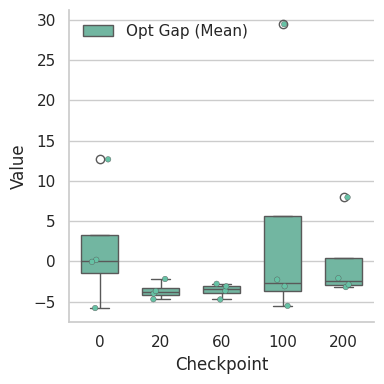

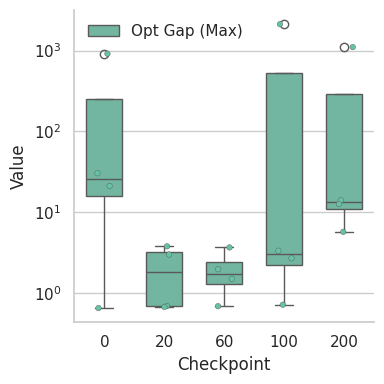

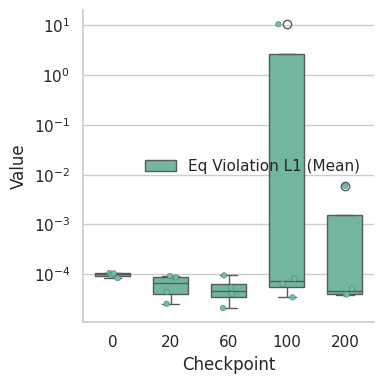

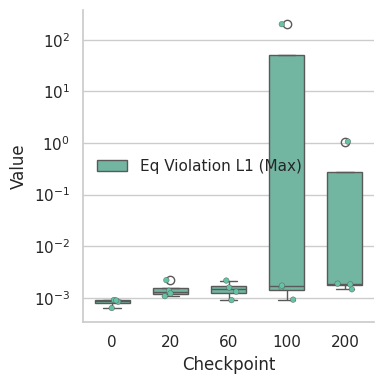

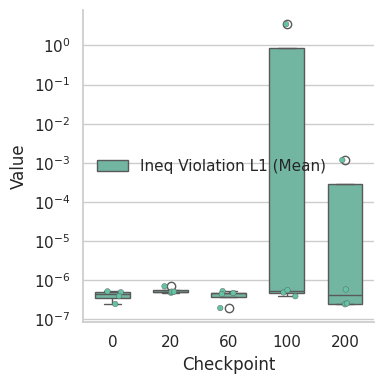

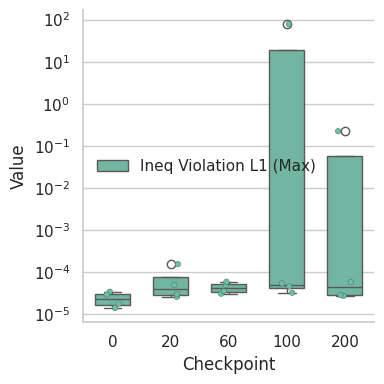

In [9]:
checkpoints = np.array([0, 20, 60, 100, 200])

plot_box_with_points(
    [opt_gap_mean],
    ["Opt Gap (Mean)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=False,
    figsize=(4, 4),
)

plot_box_with_points(
    [opt_gap_max],
    ["Opt Gap (Max)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [eq_violation_l1_mean],
    ["Eq Violation L1 (Mean)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [eq_violation_l1_max],
    ["Eq Violation L1 (Max)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [ineq_violation_l1_mean],
    ["Ineq Violation L1 (Mean)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

plot_box_with_points(
    [ineq_violation_l1_max],
    ["Ineq Violation L1 (Max)"],
    checkpoints,
    x_label="Checkpoint",
    title="",
    log_scale_y=True,
    figsize=(4, 4),
)

In [10]:
def plot_metric_over_epochs(
    metric_array,
    checkpoints,
    *,
    epochs_per_val=20,
    metric_name="Metric",
    title=None,
    log_scale_y=False,
    log_scale_x=False,
    linthresh=1e-2,
    figsize=(8, 5),
    alpha_fill=0.1,
):
    """
    Plot the evolution of a metric over validation epochs for multiple checkpoints.

    Args:
        metric_array: np.ndarray of shape (num_ckpts, num_seeds, num_epochs)
        checkpoints: list of checkpoint identifiers (same length as first axis)
        epochs_per_val: multiply index by this to get actual epoch count
        metric_name: y-axis label
        title: optional plot title (default based on metric_name)
        log_scale_y: use symlog y-scale for better visibility
        linthresh: linear threshold for symlog
        figsize: figure size
        alpha_fill: transparency for std shading
    """
    num_ckpts = metric_array.shape[0]
    num_epochs = metric_array.shape[2]
    epochs = np.arange(num_epochs) * epochs_per_val

    colors = plt.cm.tab10(np.linspace(0, 1, num_ckpts))

    plt.figure(figsize=figsize)
    for i, ckpt in enumerate(checkpoints):
        mean_ = metric_array[i].mean(axis=0)
        std_  = metric_array[i].std(axis=0)

        plt.plot(
            epochs, mean_,
            label=f"Checkpoint {ckpt}",
            color=colors[i],
            lw=2.0,
            alpha=0.9,
        )
        plt.fill_between(
            epochs,
            mean_ - std_,
            mean_ + std_,
            color=colors[i],
            alpha=alpha_fill,
            linewidth=0,
        )

    # --- Styling ---
    if log_scale_x:
        plt.xscale("log")
    if log_scale_y:
        plt.yscale("symlog", linthresh=linthresh)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    plt.title(title or f"Validation {metric_name} per Checkpoint", fontsize=13, weight="bold")
    plt.legend(frameon=True, facecolor="white", framealpha=0.9, fontsize=9, loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [11]:
# assuming you already have: dir_path_seeds, rel_path
num_ckpts = dir_path_seeds.shape[0]
num_seeds = dir_path_seeds.shape[1]
print(num_ckpts, num_seeds)

# read one file to know number of epochs
with open(os.path.join(rel_path, dir_path_seeds[0, 0], "results.pkl"), "rb") as f:
    results = pickle.load(f)
    num_epochs = len(results["val_history"])

# store [num_ckpts, num_seeds, num_epochs]
opt_gap_mean_epochs = np.zeros((num_ckpts, num_seeds, num_epochs))

for i in range(num_ckpts):  # over ckpt
    for j in range(num_seeds):  # over seed
        dir_path = os.path.join(rel_path, dir_path_seeds[i, j])
        with open(os.path.join(dir_path, "results.pkl"), "rb") as f:
            results = pickle.load(f)
            results_ = results["val_history"]
            opt_gap_mean_epochs[i, j, :] = [r["opt_gap_mean"] for r in results_]

5 4


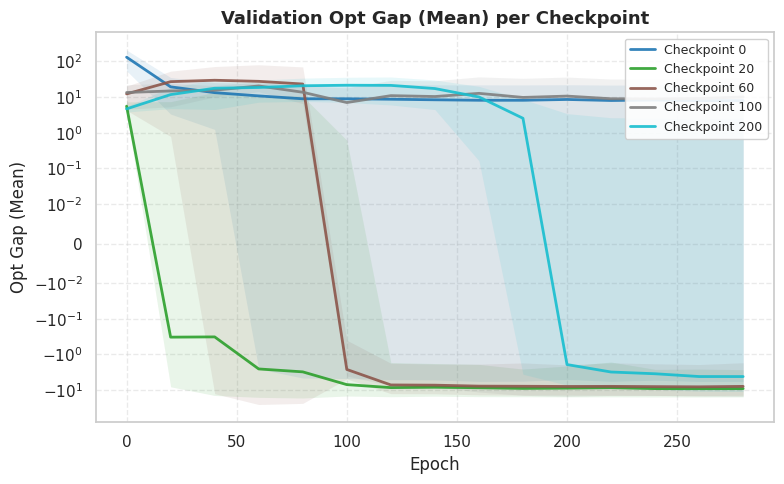

In [12]:
plot_metric_over_epochs(
    metric_array=opt_gap_mean_epochs,   # shape [num_ckpts, num_seeds, num_epochs]
    checkpoints=[0, 20, 60, 100, 200],
    metric_name="Opt Gap (Mean)",
    # title="Validation Opt Gap Mean per Checkpoint",
    log_scale_y=True,        # set False if values are small
    epochs_per_val=20,
)